missing values per column:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
0
fix data types
explatory data analysis
class
0    136961
1     14151
Name: count, dtype: int64
fraud rate;9.36 %


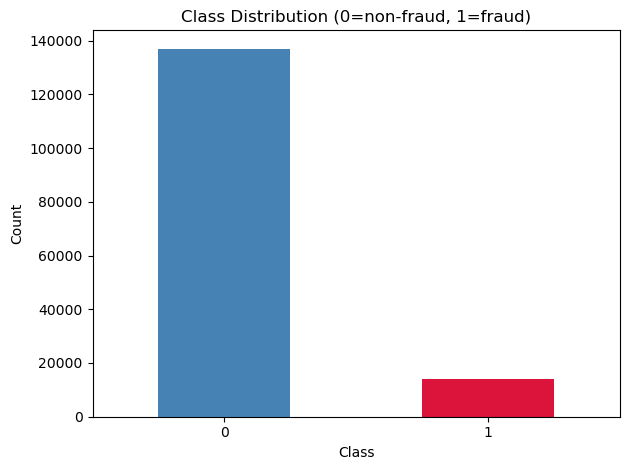

univariate purcahse value


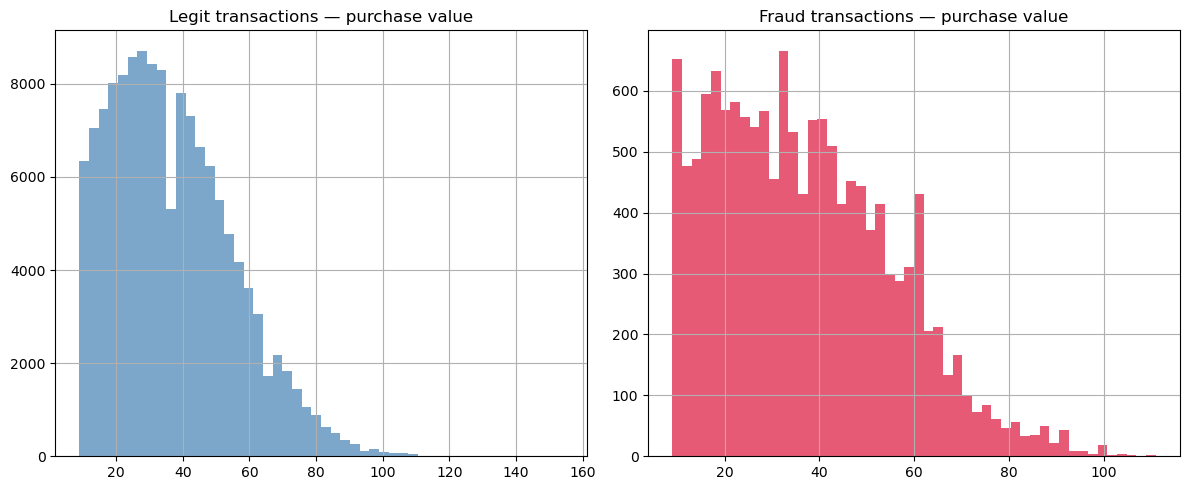

categorical features vs fraud rate


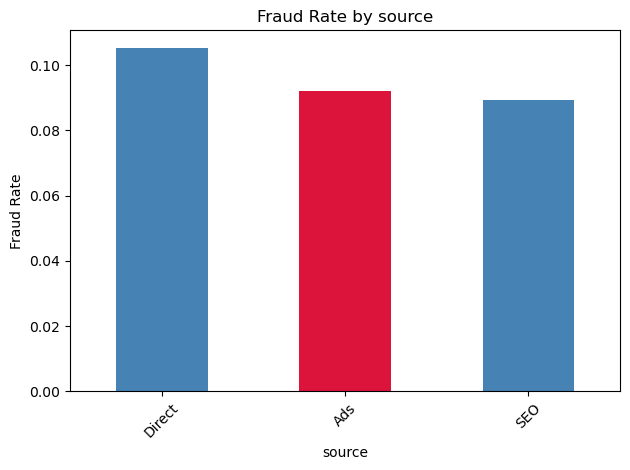

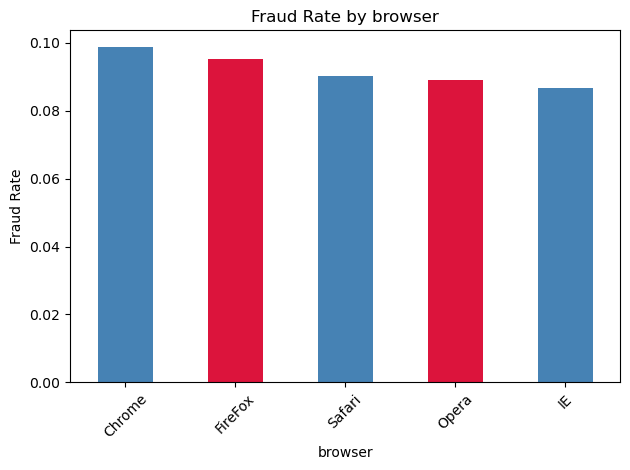

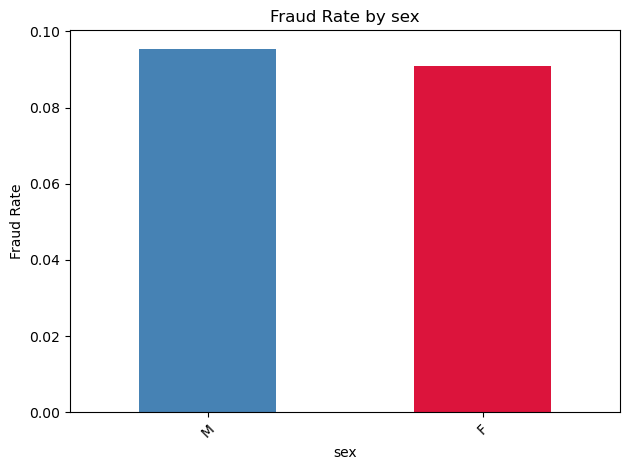

geolocational analysis
ip converted to integer


ValueError: Merge keys contain null values on left side

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress

from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../data/Fraud_Data .csv')
df_ip=pd.read_csv('../data/IpAddress_to_Country.csv')
df.head()
print("missing values per column:")
print(df.isnull().sum())

print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('fix data types')

print("explatory data analysis")
#classimbalance
counts=df['class'].value_counts()
print(counts)
print(f"fraud rate;{counts[1]/len(df) *100:.2f} %")
counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Class Distribution (0=non-fraud, 1=fraud)')
plt.xticks(rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("univariate purcahse value")
fig,axes=plt.subplots(1,2,figsize=(12,5))
df[df['class']==0]['purchase_value'].hist(ax=axes[0], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Legit transactions — purchase value')
df[df['class']==1]['purchase_value'].hist(ax=axes[1], bins=50, color='crimson', alpha=0.7)
axes[1].set_title('Fraud transactions — purchase value')
plt.tight_layout()
plt.show()

print("categorical features vs fraud rate")
for col in ['source','browser', 'sex']:
    fraude_rate=df.groupby(col)['class'].mean().sort_values(ascending=False)
    fraude_rate.plot(kind='bar', color=['steelblue', 'crimson'])
    plt.title(f'Fraud Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Fraud Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
print("geolocational analysis")
def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(str(ip).strip()))
    except Exception:
        return np.nan
df['ip_int']=df['ip_address'].apply(ip_to_int)
df_ip['lower_int']=df_ip['lower_bound_ip_address'].apply(ip_to_int)
df_ip['upper_int']=df_ip['upper_bound_ip_address'].apply(ip_to_int)
print("ip converted to integer")
df[['ip_address','ip_int']].head(3)

#range-based merge (merge_asof)
# Sort both dataframes by the IP integer column
df_sorted = df.sort_values('ip_int').reset_index(drop=True)
df_ip_sorted    = df_ip.sort_values('lower_int').reset_index(drop=True)

# Merge: for each transaction IP, find the IP range it falls in
merged = pd.merge_asof(
    df_sorted,
    df_ip_sorted[['lower_int', 'upper_int', 'country']],
    left_on='ip_int',
    right_on='lower_int',
    direction='backward'
)

# Keep only rows where ip_int <= upper_int (valid range)
merged['country'] = np.where(
    merged['ip_int'] <= merged['upper_int'],
    merged['country'],
    'Unknown'
)

print("Country mapped ✓")
print(merged['country'].value_counts().head(10))


top_countries = (
    merged.groupby('country')['class']
    .agg(['mean','count'])
    .rename(columns={'mean':'fraud_rate','count':'transactions'})
    .query('transactions > 100')          # only countries with enough data
    .sort_values('fraud_rate', ascending=False)
    .head(15)
)

top_countries['fraud_rate'].plot(kind='bar', color='crimson', alpha=0.8)
plt.title('Fraud rate by country (top 15)')
plt.ylabel('Fraud rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
         

